In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

Cek Data

In [ ]:
klaim = pd.read_csv("Data_Klaim.csv")
polis = pd.read_csv("Data_Polis.csv")

In [ ]:
polis.head()

,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,POL-0001,M-003,M,19640811,20140603,JAKARTA
1,POL-0002,M-003,M,19710730,20140603,JAKARTA
2,POL-0003,M-001,M,19790821,20160808,JAKARTA
3,POL-0004,M-003,M,20140724,20160811,JAKARTA
4,POL-0005,M-001,F,19810114,20150828,JAKARTA


In [ ]:
klaim.head()

,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,191424386.0,1.914244e+08,Singapore
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-06,2024-06-06,138936357.0,1.389364e+08,Singapore


In [ ]:
df = pd.merge(
    klaim,
    polis,
    on="Nomor Polis",
    how="left"
)

df_copy = df.copy()

In [ ]:
df_copy = df_copy[['Claim ID', 'Nomor Polis', 'Plan Code' ,'Gender', 'Tanggal Lahir', 'Tanggal Efektif Polis', 'Domisili', 'Reimburse/Cashless','Inpatient/Outpatient', 'ICD Diagnosis', 'ICD Description', 'Status Klaim', 'Tanggal Pembayaran Klaim','Tanggal Pasien Masuk RS','Tanggal Pasien Keluar RS', 'Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi','Lokasi RS']]

In [ ]:
df_copy['Tanggal Lahir'] = pd.to_datetime(df_copy['Tanggal Lahir'], format="%Y%m%d")
df_copy['Tanggal Efektif Polis'] = pd.to_datetime(df_copy['Tanggal Efektif Polis'], format="%Y%m%d")
df_copy['Tanggal Pembayaran Klaim'] = pd.to_datetime(df_copy['Tanggal Pembayaran Klaim'], format="%Y-%m-%d")
df_copy['Tanggal Pasien Masuk RS'] = pd.to_datetime(df_copy['Tanggal Pasien Masuk RS'], format="%Y-%m-%d")
df_copy['Tanggal Pasien Keluar RS'] = pd.to_datetime(df_copy['Tanggal Pasien Keluar RS'], format="%Y-%m-%d")
df_copy['Nominal Klaim Yang Disetujui'] = pd.to_numeric(df_copy['Nominal Klaim Yang Disetujui'], errors='coerce')

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Claim ID                       4627 non-null   object        
 1   Nomor Polis                    4627 non-null   object        
 2   Plan Code                      4627 non-null   object        
 3   Gender                         4627 non-null   object        
 4   Tanggal Lahir                  4627 non-null   datetime64[ns]
 5   Tanggal Efektif Polis          4627 non-null   datetime64[ns]
 6   Domisili                       4627 non-null   object        
 7   Reimburse/Cashless             4627 non-null   object        
 8   Inpatient/Outpatient           4590 non-null   object        
 9   ICD Diagnosis                  4621 non-null   object        
 10  ICD Description                4621 non-null   object        
 11  Status Klaim     

In [ ]:
df = df.sort_values(by='Tanggal Pasien Masuk RS')
start = '2024-01-01'
end   = '2024-01-07'

week1 = df[
    (df['Tanggal Pasien Masuk RS'] >= start) &
    (df['Tanggal Pasien Masuk RS'] <= end)
]
week1.reset_index()

,index,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,2810,C-3627-M,POL-3872,C,IP,B34.2,"CORONAVIRUS INFECTION, UNSPECIFIED SITE",PAID,2024-04-25,2024-01-01,2024-01-07,14741310.0,1.502575e+07,Indonesia,M-002,F,19420416,20120307,JAKARTA
1,3006,C-3836-M,POL-2078,C,OP,N18.5,"CHRONIC KIDNEY DISEASE, STAGE 5",PAID,2024-04-05,2024-01-02,2024-01-02,2769687.0,3.400335e+06,Indonesia,M-002,M,19680307,20121109,SURABAYA
2,2816,C-3636-M,POL-3932,C,IP,H82,VERTIGINOUS SYNDROMES IN DISEASES CLASSIFIED E...,PAID,2024-02-06,2024-01-02,2024-01-07,36417500.0,3.641750e+07,Indonesia,M-002,M,19640505,20151113,SURABAYA
3,1948,C-2519-M,POL-2436,R,IP,H35,OTHER RETINAL DISORDERS,PAID,2024-01-17,2024-01-02,2024-01-02,15667000.0,1.566700e+07,Indonesia,M-002,M,19510518,20121012,SURABAYA
4,144,C-0245-M,POL-2200,C,OP,N23,UNSPECIFIED RENAL COLIC,PAID,2024-04-25,2024-01-02,2024-01-02,1839000.0,1.870000e+06,Indonesia,M-003,F,19740531,20160218,JAKARTA
5,2921,C-3744-M,POL-3045,C,OP,N18.6,END STAGE RENAL DISEASE,PAID,2024-04-16,2024-01-02,2024-01-02,2101663.0,2.101663e+06,Indonesia,M-002,M,19690929,20141125,PALEMBANG
6,4406,C-5488-M,POL-1450,R,IP,B34.2,"CORONAVIRUS INFECTION, UNSPECIFIED SITE",PAID,2024-01-29,2024-01-02,2024-01-09,42893312.0,4.503769e+07,Indonesia,M-003,M,19510911,20120727,SURABAYA
7,2461,C-3233-M,POL-1662,C,IP,H18,OTHER DISORDERS OF CORNEA,PAID,2024-04-30,2024-01-02,2024-01-02,2510000.0,2.854289e+06,Indonesia,M-003,F,19551123,20150328,JAKARTA
8,462,C-0637-M,POL-2506,R,IP,G44,OTHER HEADACHE SYNDROMES,PAID,2024-02-13,2024-01-02,2024-01-07,30955000.0,3.095500e+07,Indonesia,M-003,F,19551213,20171219,JEMBER
9,2822,C-3642-M,POL-2702,C,IP,B34.2,"CORONAVIRUS INFECTION, UNSPECIFIED SITE",PAID,2024-01-30,2024-01-03,2024-01-03,11637510.0,1.188565e+07,Indonesia,M-003,M,19480419,20150304,JAKARTA


In [ ]:
week1['Claim ID'].count()

np.int64(46)

In [ ]:
week1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46 entries, 2810 to 2034
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Claim ID                       46 non-null     object 
 1   Nomor Polis                    46 non-null     object 
 2   Reimburse/Cashless             46 non-null     object 
 3   Inpatient/Outpatient           44 non-null     object 
 4   ICD Diagnosis                  46 non-null     object 
 5   ICD Description                46 non-null     object 
 6   Status Klaim                   46 non-null     object 
 7   Tanggal Pembayaran Klaim       46 non-null     object 
 8   Tanggal Pasien Masuk RS        46 non-null     object 
 9   Tanggal Pasien Keluar RS       46 non-null     object 
 10  Nominal Klaim Yang Disetujui   46 non-null     object 
 11  Nominal Biaya RS Yang Terjadi  46 non-null     float64
 12  Lokasi RS                      46 non-null     objec

In [ ]:
week1['Nominal Klaim Yang Disetujui'] = pd.to_numeric(
    week1['Nominal Klaim Yang Disetujui'], errors='coerce'
)

/tmp/ipykernel_4090/31802937.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  week1['Nominal Klaim Yang Disetujui'] = pd.to_numeric(


In [ ]:
week1['Nominal Klaim Yang Disetujui'].sum()

np.float64(2433246023.8)

buat kolom baru

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Claim ID                       4627 non-null   object        
 1   Nomor Polis                    4627 non-null   object        
 2   Plan Code                      4627 non-null   object        
 3   Gender                         4627 non-null   object        
 4   Tanggal Lahir                  4627 non-null   datetime64[ns]
 5   Tanggal Efektif Polis          4627 non-null   datetime64[ns]
 6   Domisili                       4627 non-null   object        
 7   Reimburse/Cashless             4627 non-null   object        
 8   Inpatient/Outpatient           4590 non-null   object        
 9   ICD Diagnosis                  4621 non-null   object        
 10  ICD Description                4621 non-null   object        
 11  Status Klaim     

In [ ]:
today = datetime.today()
df_copy['umur'] = df_copy['Tanggal Lahir'].apply(
    lambda x: today.year - x.year - (
        (today.month, today.day) < (x.month, x.day)
    )
)
#Waktu perawatan di rumah sakit
df_copy['waktu_perawatan'] = df_copy['Tanggal Pasien Keluar RS'] - df_copy['Tanggal Pasien Masuk RS']
df_copy['waktu_perawatan'] = df_copy['waktu_perawatan'].dt.days

#Mengelompokan diagnosis penyakit berdasarkan icd 10
df_copy['icd_category'] = df_copy['ICD Diagnosis'].astype(str).str.upper().str[0]

icd_group_map = {
    'A': 'Infeksi',
    'B': 'Infeksi',
    'C': 'Kanker',
    'D': 'Tumor & Darah',
    'E': 'Endokrin & Metabolik',
    'F': 'Mental',
    'G': 'Saraf',
    'H': 'Mata & Telinga',
    'I': 'Kardiovaskular',
    'J': 'Respirasi',
    'K': 'Pencernaan',
    'L': 'Kulit',
    'M': 'Muskuloskeletal',
    'N': 'Genitourinaria',
    'R': 'Gejala',
    'S': 'Trauma',
    'T': 'Trauma',
    'Z': 'Faktor Kesehatan'
}

df_copy['diagnosis_group'] = df_copy['icd_category'].map(icd_group_map)

**EDA**

agregat data

In [ ]:
df_copy = df_copy.set_index('Tanggal Pasien Masuk RS')

weekly_df = df_copy.resample('W').agg(
    frekuensi=('Claim ID', 'count'),
    total_nominal_klaim=('Nominal Klaim Yang Disetujui', 'sum'),

    avg_age=("umur", "mean"),

    mean_biaya_rs=("Nominal Biaya RS Yang Terjadi", "mean"),
    median_biaya_rs=("Nominal Biaya RS Yang Terjadi", "median"),

    mean_los=("waktu_perawatan", "mean"),

    inpatient_count=("Inpatient/Outpatient", lambda x: (x == "IP").sum()),
    cashless_count=("Reimburse/Cashless", lambda x: (x == "Cashless").sum()),

    male_count=("Gender", lambda x: (x == "M").sum()),

    kanker_count=("diagnosis_group", lambda x: (x == "Kanker").sum()),
    genitourinaria_count=("diagnosis_group", lambda x: (x == "Genitourinaria").sum()),
    mata_telinga_count=("diagnosis_group", lambda x: (x == "Mata & Telinga").sum()),

    lokasi_ind=("Lokasi RS", lambda x: (x == "Indonesia").sum()),
    lokasi_sg=("Lokasi RS", lambda x: (x == "Singapore").sum()),
    lokasi_malay=("Lokasi RS", lambda x: (x == "Malaysia").sum()),
)

# target turunan
weekly_df['severitas'] = weekly_df['total_nominal_klaim'] / weekly_df['frekuensi']

# ratio features
weekly_df['pct_inpatient'] = weekly_df['inpatient_count'] / weekly_df['frekuensi']
weekly_df['pct_cashless'] = weekly_df['cashless_count'] / weekly_df['frekuensi']
weekly_df['pct_male'] = weekly_df['male_count'] / weekly_df['frekuensi']

weekly_df['pct_kanker'] = weekly_df['kanker_count'] / weekly_df['frekuensi']
weekly_df['pct_genitourinaria'] = weekly_df['genitourinaria_count'] / weekly_df['frekuensi']
weekly_df['pct_mata_telinga'] = weekly_df['mata_telinga_count'] / weekly_df['frekuensi']

weekly_df['pct_ind'] = weekly_df['lokasi_ind'] / weekly_df['frekuensi']
weekly_df['pct_sg'] = weekly_df['lokasi_sg'] / weekly_df['frekuensi']
weekly_df['pct_malay'] = weekly_df['lokasi_malay'] / weekly_df['frekuensi']

# drop count columns
weekly_df = weekly_df.drop(columns=[
    'inpatient_count',
    'cashless_count',
    'male_count',
    'kanker_count',
    'genitourinaria_count',
    'mata_telinga_count',
    'lokasi_ind',
    'lokasi_sg',
    'lokasi_malay'
])

weekly_df = weekly_df.reset_index()
weekly_df = weekly_df.rename(columns={'Tanggal Pasien Masuk RS': 'waktu'})

In [ ]:
weekly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   waktu                83 non-null     datetime64[ns]
 1   frekuensi            83 non-null     int64         
 2   total_nominal_klaim  83 non-null     float64       
 3   avg_age              83 non-null     float64       
 4   mean_biaya_rs        83 non-null     float64       
 5   median_biaya_rs      83 non-null     float64       
 6   mean_los             83 non-null     float64       
 7   severitas            83 non-null     float64       
 8   pct_inpatient        83 non-null     float64       
 9   pct_cashless         83 non-null     float64       
 10  pct_male             83 non-null     float64       
 11  pct_kanker           83 non-null     float64       
 12  pct_genitourinaria   83 non-null     float64       
 13  pct_mata_telinga     83 non-null     

In [ ]:
weekly_df.head()

,waktu,frekuensi,total_nominal_klaim,avg_age,mean_biaya_rs,median_biaya_rs,mean_los,severitas,pct_inpatient,pct_cashless,pct_male,pct_kanker,pct_genitourinaria,pct_mata_telinga,pct_ind,pct_sg,pct_malay
0,2024-01-07,46,2.433246e+09,61.521739,5.663807e+07,15346374.5,1.826087,5.289665e+07,0.586957,0.0,0.413043,0.217391,0.195652,0.108696,0.739130,0.195652,0.043478
1,2024-01-14,84,5.887795e+09,62.642857,8.193885e+07,19642841.5,1.535714,7.009280e+07,0.785714,0.0,0.523810,0.214286,0.083333,0.107143,0.726190,0.190476,0.071429
2,2024-01-21,95,7.226359e+09,62.189474,1.001810e+08,17420519.0,1.694737,7.606694e+07,0.768421,0.0,0.610526,0.126316,0.136842,0.052632,0.589474,0.210526,0.126316
3,2024-01-28,48,1.788987e+09,60.604167,4.439584e+07,12196032.0,1.312500,3.727055e+07,0.625000,0.0,0.583333,0.229167,0.145833,0.083333,0.708333,0.208333,0.062500
4,2024-02-04,51,3.758074e+09,58.980392,8.018652e+07,20780500.0,1.333333,7.368772e+07,0.568627,0.0,0.509804,0.294118,0.196078,0.019608,0.725490,0.235294,0.019608


In [ ]:
weekly_df[['waktu','severitas']]

,waktu,severitas
0,2024-01-07,5.289665e+07
1,2024-01-14,7.009280e+07
2,2024-01-21,7.606694e+07
3,2024-01-28,3.727055e+07
4,2024-02-04,7.368772e+07
...,...,...
78,2025-07-06,8.265583e+07
79,2025-07-13,4.799826e+07
80,2025-07-20,3.522604e+07
81,2025-07-27,4.721195e+07


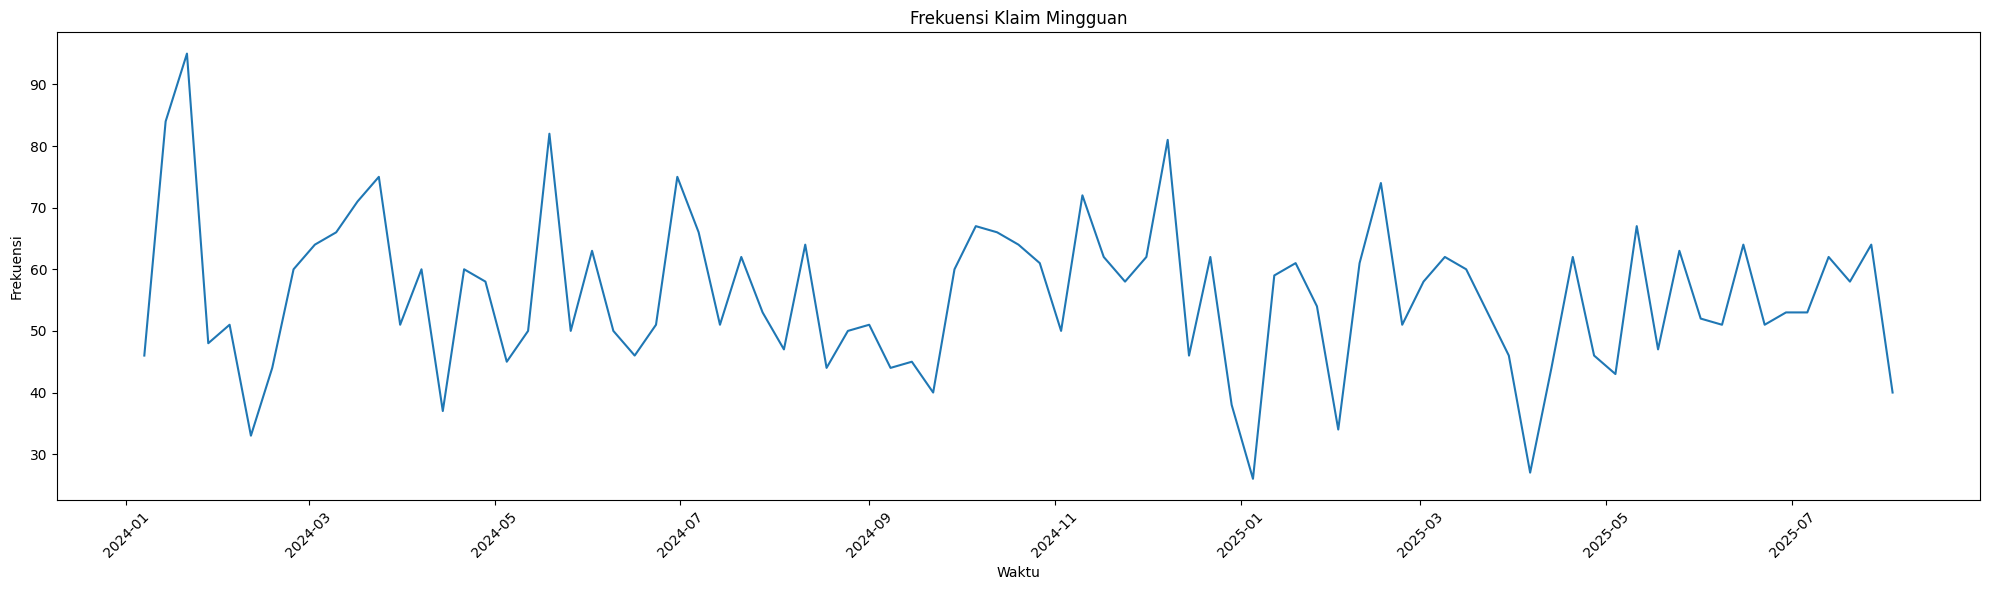

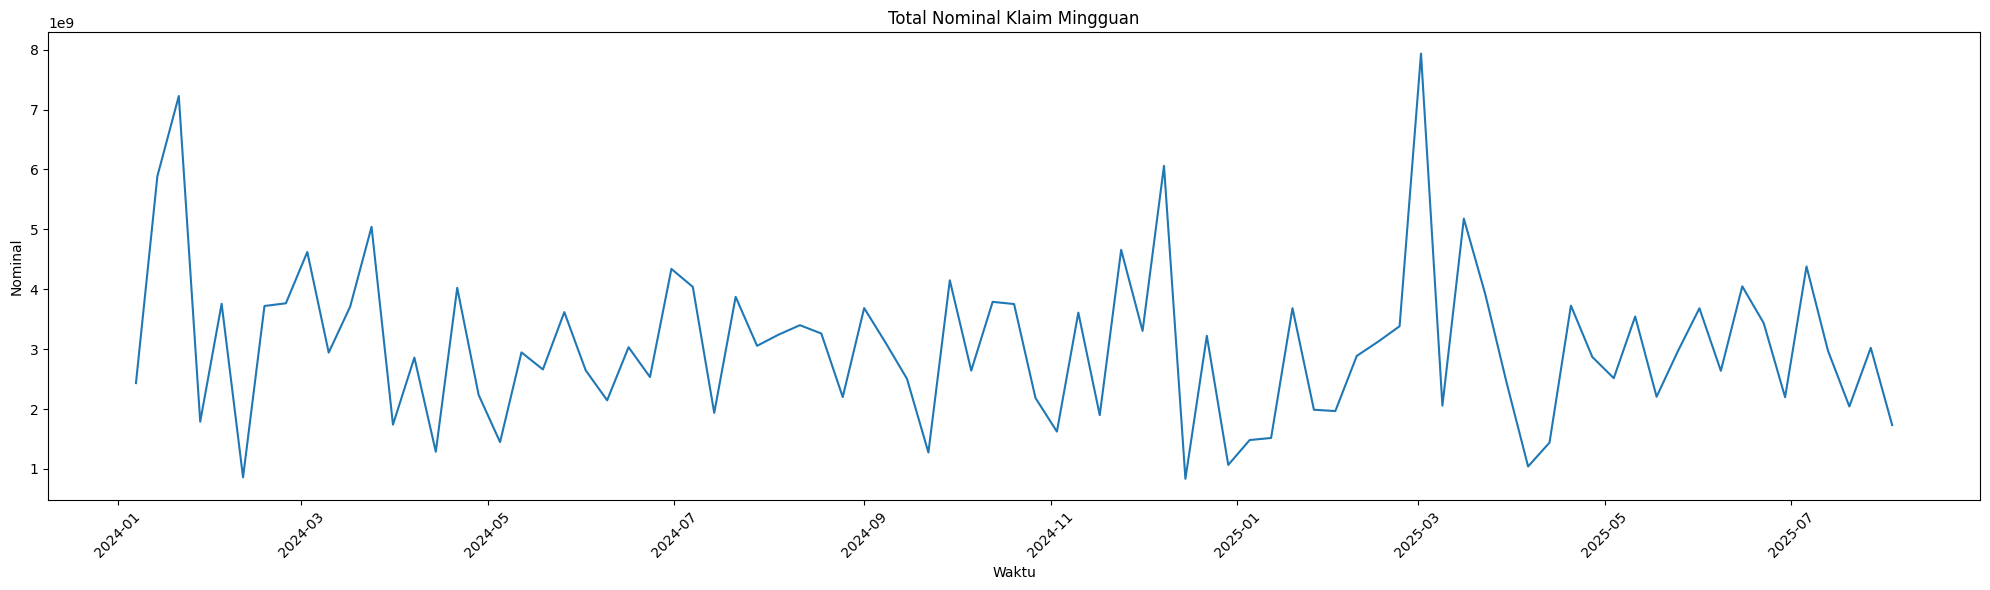

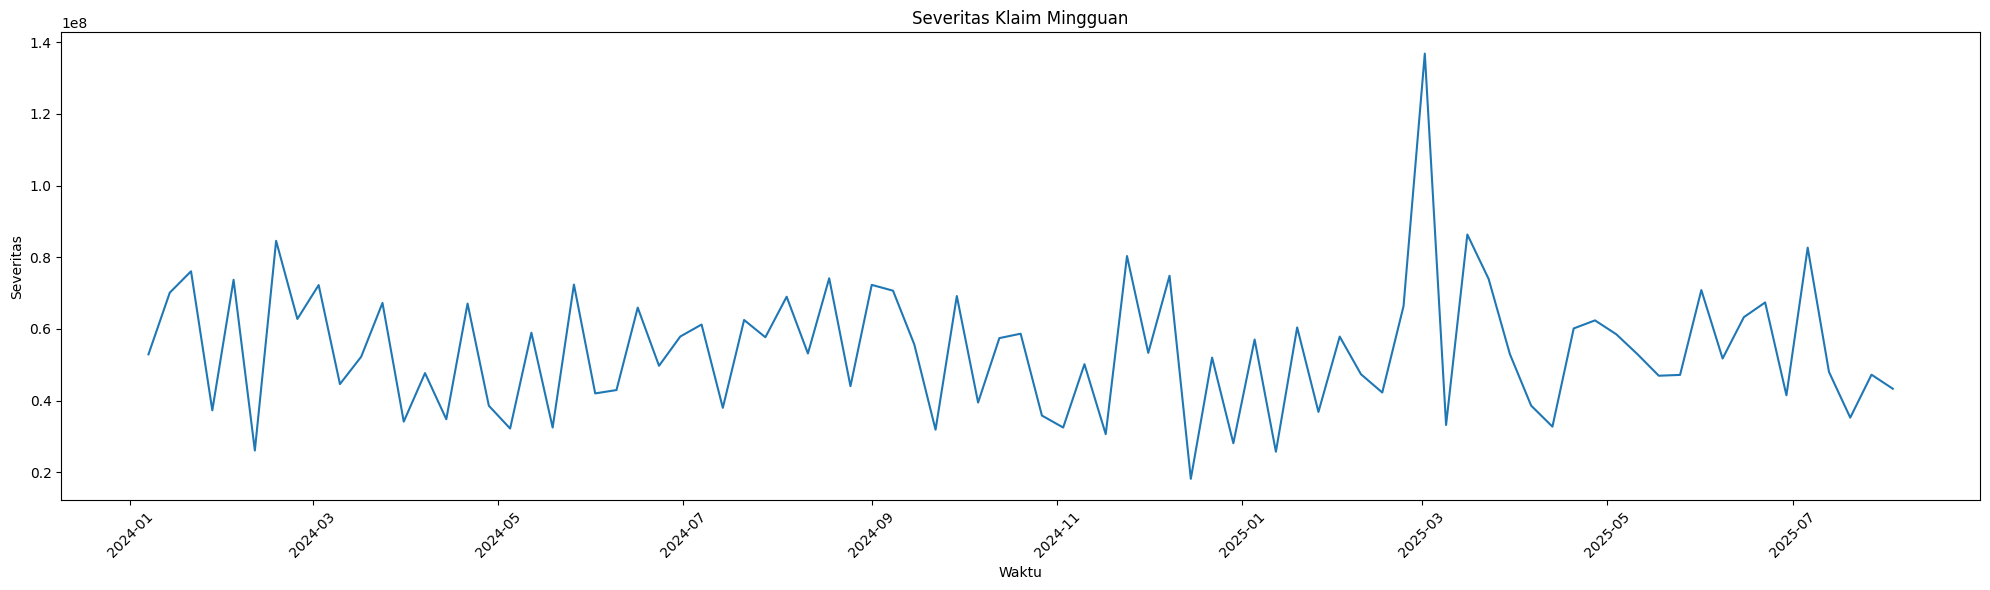

In [ ]:
import matplotlib.dates as mdates

plt.figure(figsize=(20,6))

plt.plot(weekly_df['waktu'], weekly_df['frekuensi'])

plt.title("Frekuensi Klaim Mingguan")
plt.xlabel("Waktu")
plt.ylabel("Frekuensi")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(20,6))
plt.plot(weekly_df['waktu'], weekly_df['total_nominal_klaim'])

plt.title("Total Nominal Klaim Mingguan")
plt.xlabel("Waktu")
plt.ylabel("Nominal")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(20,6))

plt.plot(weekly_df['waktu'], weekly_df['severitas'])

plt.title("Severitas Klaim Mingguan")
plt.xlabel("Waktu")
plt.ylabel("Severitas")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
weekly_df.to_csv('dataframe_baru.csv', index=False)